# Exploratory Data Analysis (EDA)

This notebook separates the exploratory analysis into smaller Jupyter cells so each step is easy to present, run, and explain during evaluation.


## Notebook Setup

The next cells import the analysis libraries, define the plotting theme, and load the processed train/validation/test splits used across the EDA workflow.


In [ ]:
# Import warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Import core data manipulation and viz libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


<details>
<summary><b>Explanation</b></summary>
<br>
This block imports standard libraries for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`), setting up our foundational tools for the EDA process.
</details>

In [2]:
# Import statistical and machine learning tools from SciPy and Scikit-Learn
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance


<details>
<summary><b>Explanation</b></summary>
<br>
This block loads all the necessary machine learning modules. We use scikit-learn tools for model construction, validation, feature scaling, and performance metrics. Having them in one place makes dependency tracking easier.
</details>

In [3]:
# Update matplotlib globals for a cohesive dark-themed aesthetic
plt.rcParams.update({
    'figure.dpi': 140,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',    # Dark grey background
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'axes.grid': True,
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

# Define custom color palettes for consistency across plots
PALETTE = {
    'primary': '#58a6ff',
    'secondary': '#bc8cff',
    'accent': '#ff7b72',
    'success': '#3fb950',
    'warning': '#d29922',
    'gradient': ['#58a6ff', '#bc8cff', '#ff7b72', '#3fb950', '#d29922', '#f778ba'],
    'sequential': sns.color_palette('mako', 10),
    'diverging': sns.color_palette('coolwarm', 10),
}

# Set globally reproducible random seed
SEED = 42
np.random.seed(SEED)
print('Environment ready for notebook execution.')


Environment ready for notebook execution.


<details>
<summary><b>Explanation</b></summary>
<br>
We establish a global dark theme and standardized color palettes so that all upcoming charts look professional and uniform. Setting a fixed random seed (`42`) guarantees that any randomized processes (like sampling) give the same results every time.
</details>

### Code Block Explanation
This cell loads the processed modeling splits and prints the basic class balance. It confirms that the dataset is available before we start plotting.


In [4]:
# ── Load pre-processed train / val / test splits ────────────────
# Define path to the processed csv files
PROC = '../data/processed/'

# Load train, val, and test data into pandas DataFrames
train = pd.read_csv(PROC + 'train.csv')
val   = pd.read_csv(PROC + 'val.csv')
test  = pd.read_csv(PROC + 'test.csv')

# Print dataset dimensions to verify everything loaded correctly
print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Val:   {val.shape[0]:,} rows × {val.shape[1]} cols')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} cols')

# Output the baseline distribution of the target variable
print(f'\nTarget column: target_repeat_within_180d')
print(f'Target distribution (train):')
print(train['target_repeat_within_180d'].value_counts(normalize=True).round(4))


Train: 36,556 rows × 46 cols
Val:   7,834 rows × 46 cols
Test:  7,834 rows × 46 cols

Target column: target_repeat_within_180d
Target distribution (train):
target_repeat_within_180d
0    0.9811
1    0.0189
Name: proportion, dtype: float64


<details>
<summary><b>Explanation</b></summary>
<br>
This code block brings in the processed data splits crafted earlier in the pipeline. We verify the row/column dimensions and print out the split ratio of our target (repeat purchase), helping us immediately identify significant class imbalances.
</details>

---
# 3 · Exploratory Data Analysis (EDA)
> Our EDA follows a principled hierarchy: **target → univariate → bivariate → multivariate → temporal → geographic → text**. Each visualisation is annotated with the statistical insight it reveals and the downstream action it motivates.

---

### Code Block Explanation
This plot shows the overall target imbalance. The left panel gives raw counts, while the right panel compresses that information into a minority-to-majority ratio so the severity of the imbalance is obvious.


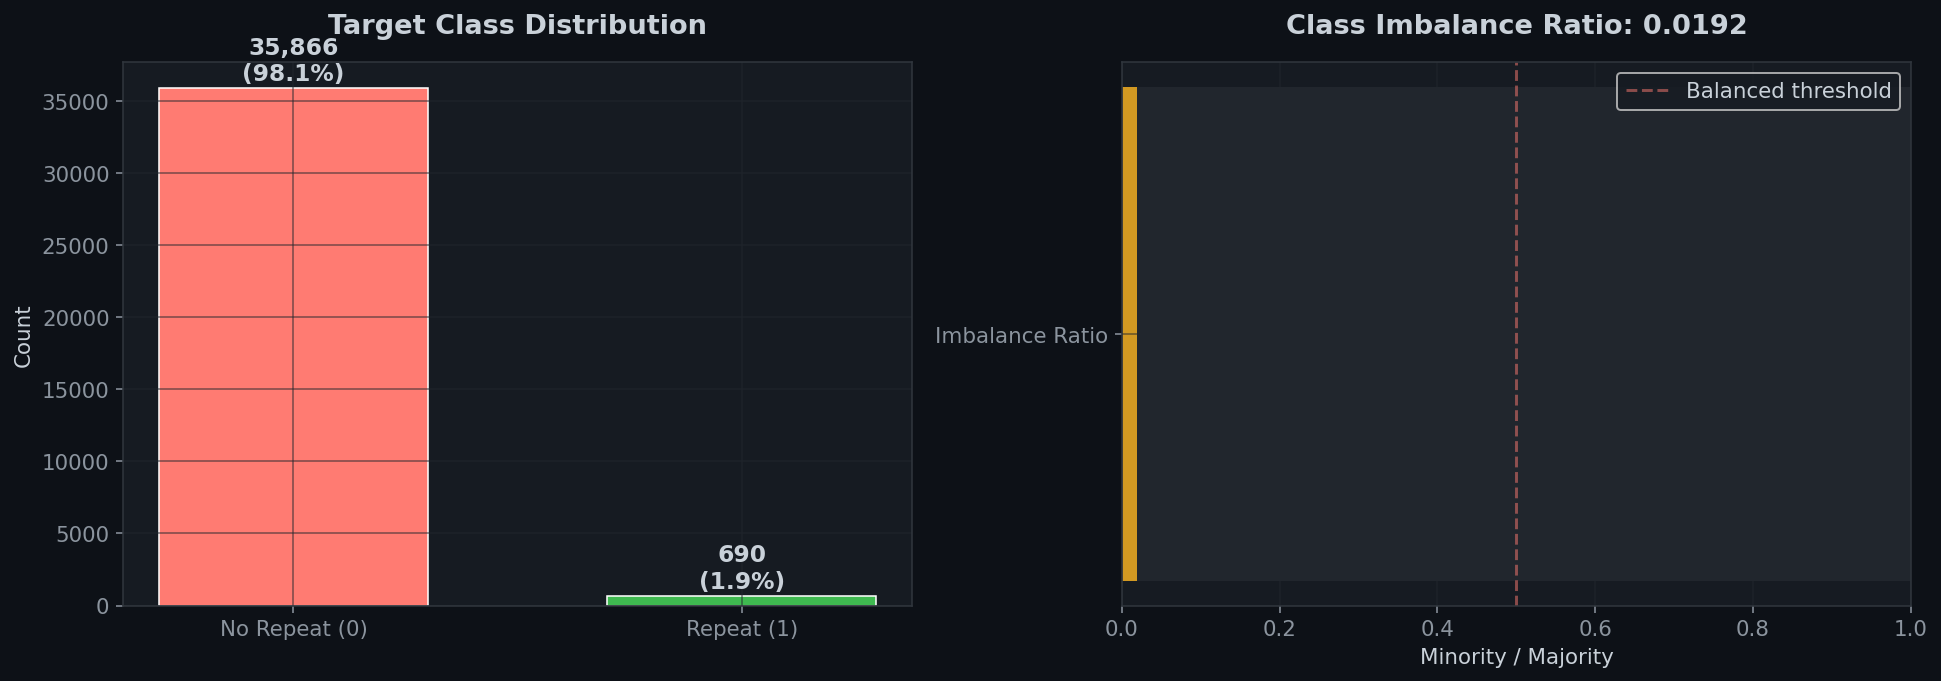

In [ ]:
# ── Target distribution ──────────────────────────────────────────
# Create a two-panel subplot figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Panel: Plot raw counts of repeat vs. non-repeat customers
counts = train['target_repeat_within_180d'].value_counts()
bars = axes[0].bar(['No Repeat (0)', 'Repeat (1)'], counts.values,
                   color=[PALETTE['accent'], PALETTE['success']],
                   edgecolor='white', linewidth=0.8, width=0.6)

# Annotate bars with counts and percentages
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}\n({count/len(train)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Target Class Distribution', pad=15)
axes[0].set_ylabel('Count')

# Right Panel: Display the severity of the class imbalance as a horizontal gauge
ratio = counts.min() / counts.max()
axes[1].barh(['Imbalance Ratio'], [ratio], color=PALETTE['warning'], height=0.3)
axes[1].barh(['Imbalance Ratio'], [1.0], color='#21262d', height=0.3) # Background bar
axes[1].barh(['Imbalance Ratio'], [ratio], color=PALETTE['warning'], height=0.3) # Foreground
axes[1].set_xlim(0, 1)
axes[1].set_title(f'Class Imbalance Ratio: {ratio:.4f}', pad=15)
axes[1].set_xlabel('Minority / Majority')
axes[1].axvline(x=0.5, color=PALETTE['accent'], linestyle='--', alpha=0.5, label='Balanced threshold')
axes[1].legend(loc='upper right')

# Save and display figure
plt.tight_layout()
plt.savefig('../final_outputs/target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
This snippet creates a visualization illustrating the class imbalance. The bar chart explicitly shows sheer volume and proportions, while the gauge chart measures the ratio between classes. Recognizing severe imbalance immediately warns us against relying on standard accuracy metrics.
</details>

### 📊 Interpretation — Target Distribution
The target variable exhibits **extreme class imbalance**: the vast majority of customers do **not** make a repeat purchase within 180 days. This finding has critical implications:

1. **Accuracy is misleading** — a naive "always predict 0" classifier would achieve >95% accuracy. We must use **F1-score, PR-AUC, and ROC-AUC** instead.
2. **Stratified splitting** is essential to preserve class ratios across train/val/test.
3. **Class weights** or **oversampling** (SMOTE) should be considered during model training.
4. This imbalance mirrors real-world CRM scenarios where repeat customers are inherently rare — making correct identification of the minority class (potential repeat buyers) the primary business objective.

## 3.2 · Univariate Distributions — Numerical Features
We characterise each numerical feature's distribution using **skewness**, **kurtosis**, and visual inspection for **heavy tails**, **multi-modality**, and **outliers**.

### Code Block Explanation
This cell computes summary statistics for every numerical feature. It helps us identify skewed variables, wide ranges, and candidates for transformation.


In [6]:
# ── Identify numerical columns ───────────────────────────────────
# Filter the df to only keep numerical formats
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Omit the target variable from descriptive statistics
exclude = ['target_repeat_within_180d']
num_cols = [c for c in num_cols if c not in exclude]

# Calculate distribution stats (mean, std dev, skewness etc.) for every numerical column
dist_stats = []
for col in num_cols:
    s = train[col].dropna()
    dist_stats.append({
        'Feature': col,
        'Mean': f'{s.mean():.2f}',
        'Std': f'{s.std():.2f}',
        'Skewness': f'{s.skew():.2f}',
        'Kurtosis': f'{s.kurtosis():.2f}',
        'Min': f'{s.min():.2f}',
        'Max': f'{s.max():.2f}',
        'Nulls': s.isna().sum()
    })

# Present these metrics neatly in a table
stats_df = pd.DataFrame(dist_stats)
print(stats_df.to_string(index=False))


                        Feature     Mean      Std Skewness Kurtosis     Min       Max  Nulls
                   review_score     4.23     1.20    -1.62     1.58    1.00      5.00      0
                   text_present     0.41     0.49     0.35    -1.88    0.00      1.00      0
                  text_char_len    26.81    46.24     2.06     3.82    0.00    207.00      0
                text_word_count     4.54     8.02     2.17     4.41    0.00     43.00      0
              exclamation_count     0.11     0.64    35.00  3141.05    0.00     66.00      0
                 question_count     0.01     0.63   177.28 32935.17    0.00    117.00      0
                    total_price   138.45   223.09    12.57   445.47    2.29  13440.00      0
                  total_freight    21.95    19.74     9.42   241.62    0.00   1002.29      0
            payment_value_total   160.43   231.87    11.96   408.91   10.07  13664.08      0
       payment_installments_max     3.09     2.82     1.50     2.01   

<details>
<summary><b>Explanation</b></summary>
<br>
Here, we compute a statistical summary for all numerical fields. Checking skewness and kurtosis tells us if data is heavily right-tailed (needing log-transformation), while 'Nulls' verifies if missing values require imputation.
</details>

### Interpretation — Distribution Statistics
- Features with **|skewness| > 2** (e.g., `total_price`, `total_freight`, `product_weight_g_mean`) exhibit **heavy right tails** — log transformation is recommended.
- Features with **high kurtosis** (heavy tails & peaked distributions) may contain **influential outliers** that warrant capping.
- The pre-processed data already includes `log1p_*` variants for the most skewed features — we will validate their effectiveness.

### Code Block Explanation
This plot compares the raw and log-transformed versions of the most skewed monetary and product-size variables. It shows whether the transforms make the distributions more stable for downstream modeling.


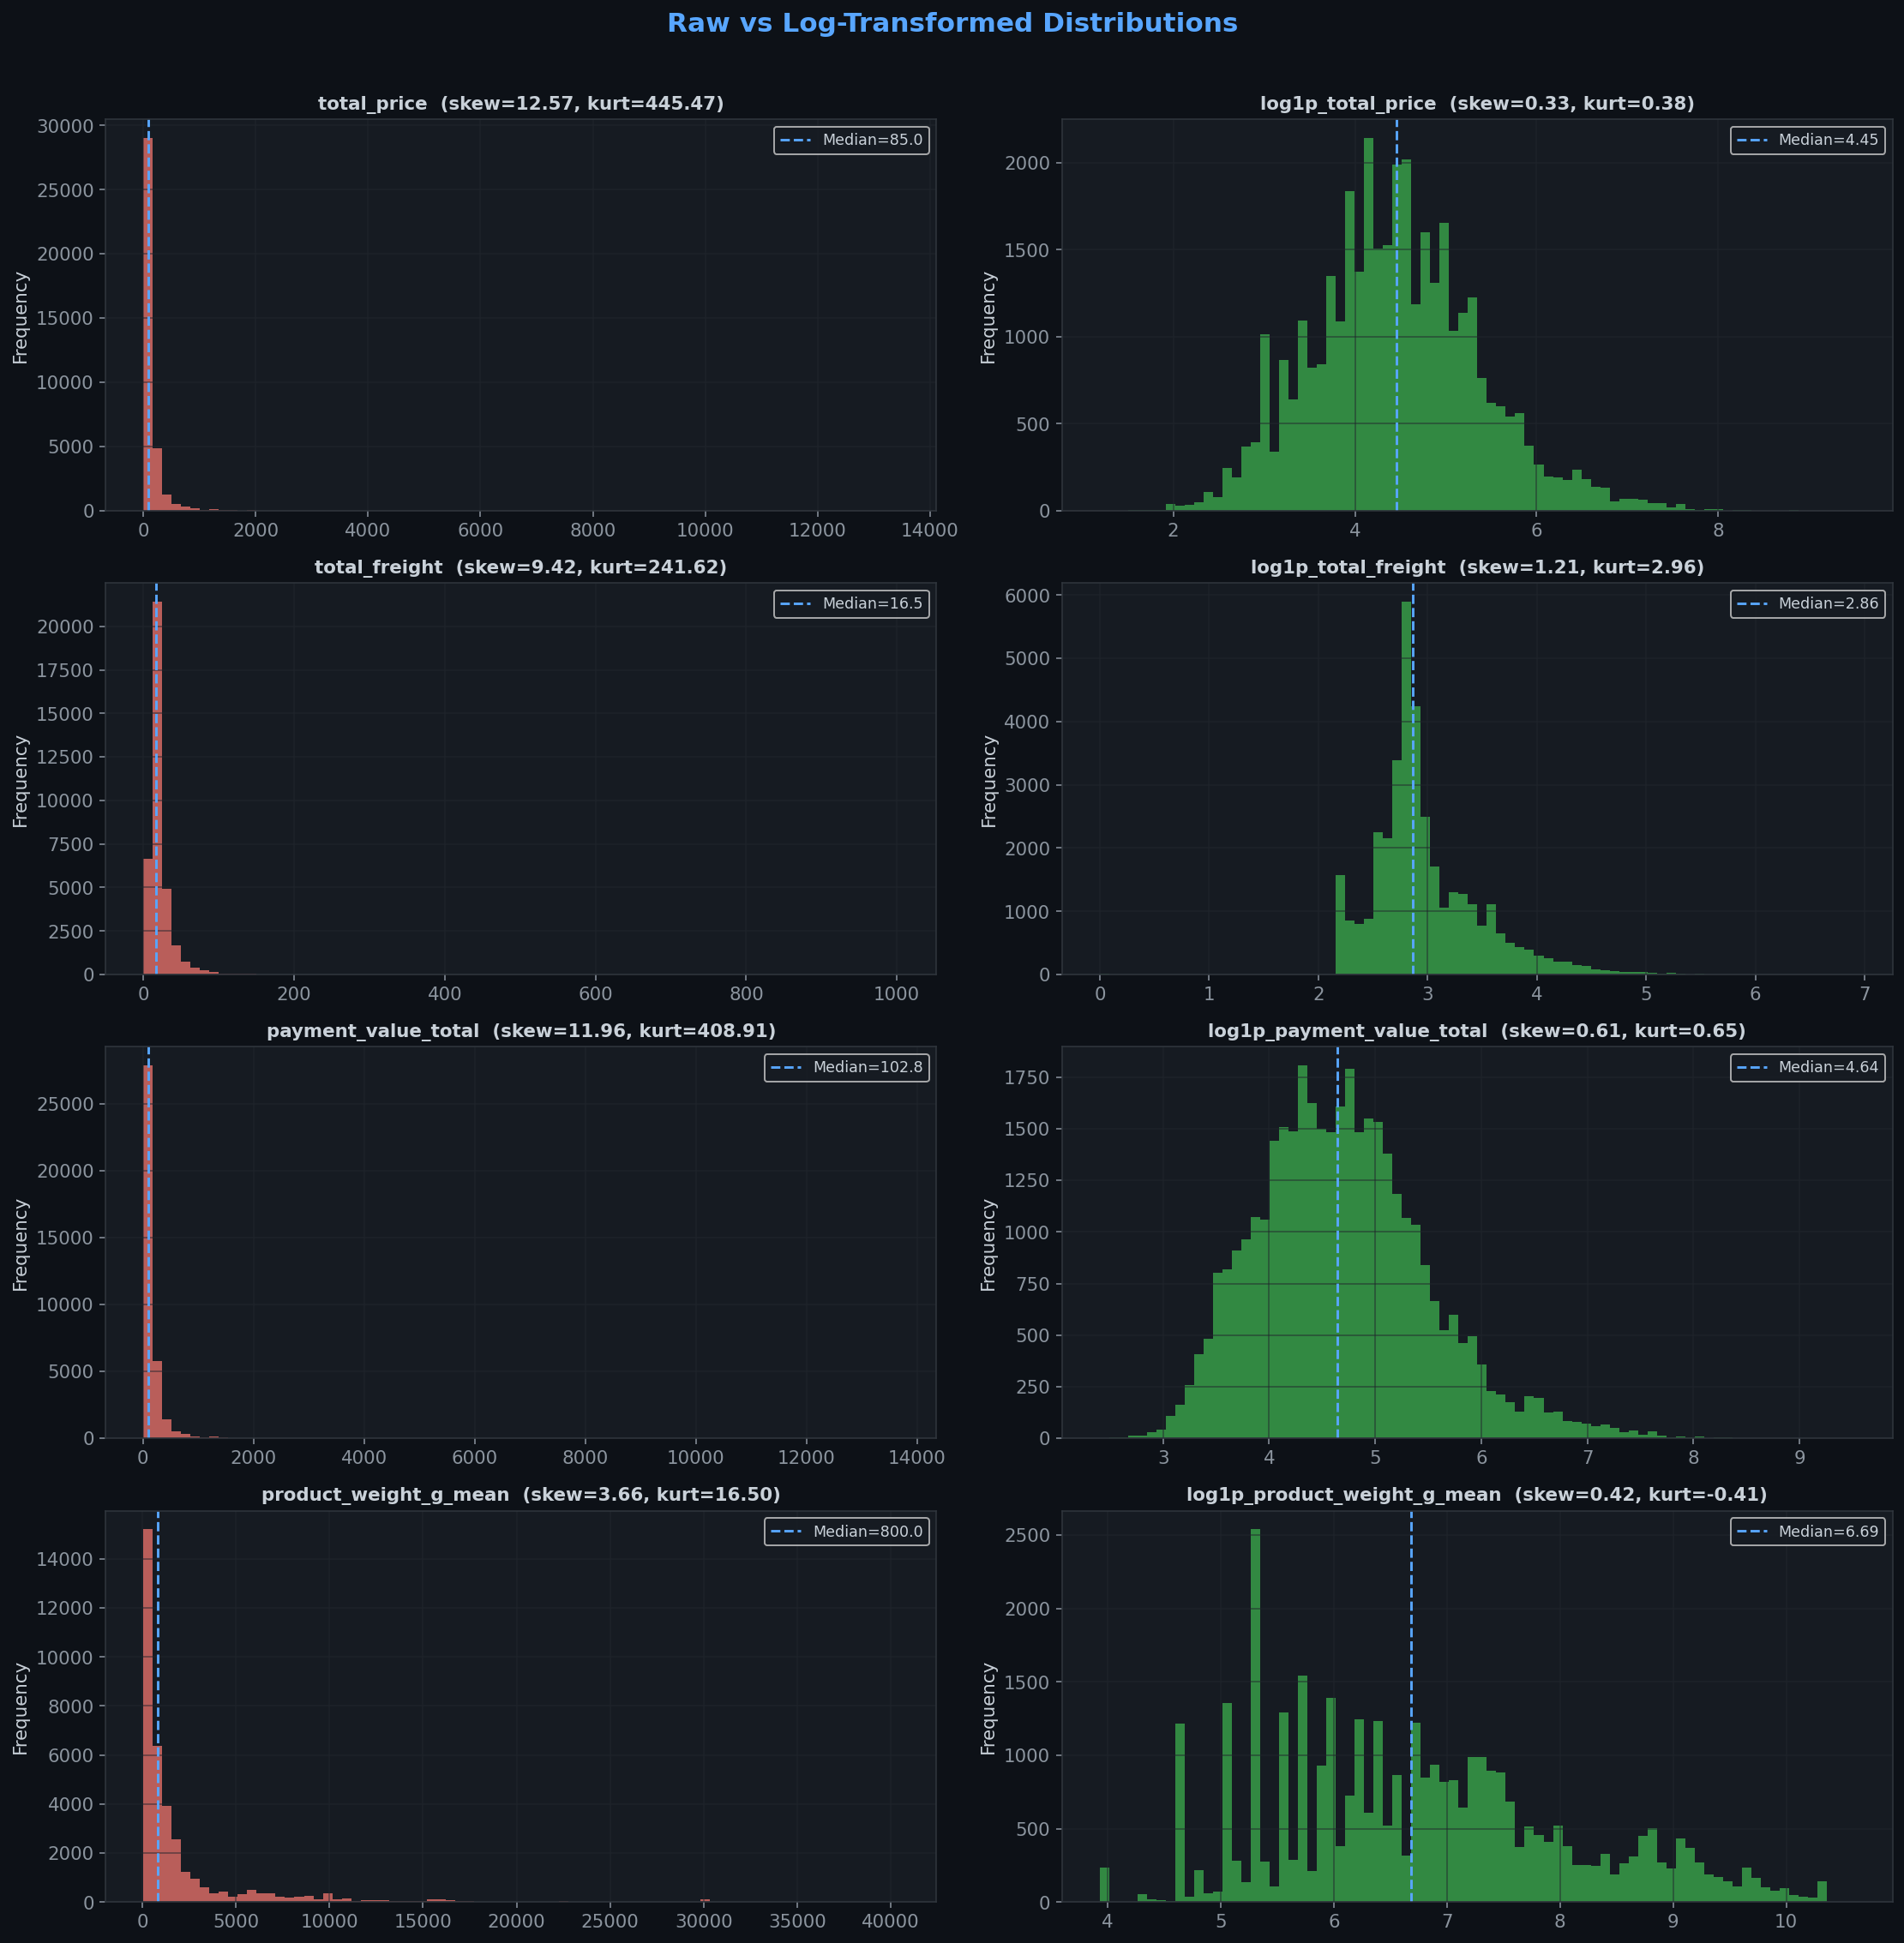

In [7]:
# ── Distribution grid: Raw vs Log-transformed ───────────────────
# Paired tuples of raw feature vs its pre-logged equivalent
raw_log_pairs = [
    ('total_price', 'log1p_total_price'),
    ('total_freight', 'log1p_total_freight'),
    ('payment_value_total', 'log1p_payment_value_total'),
    ('product_weight_g_mean', 'log1p_product_weight_g_mean'),
]

# Create a grid mapping pairs side-by-side
fig, axes = plt.subplots(len(raw_log_pairs), 2, figsize=(16, 4*len(raw_log_pairs)))

for i, (raw, logged) in enumerate(raw_log_pairs):
    # Left plot: original highly-skewed raw distribution
    ax_raw = axes[i, 0]
    data_raw = train[raw].dropna()
    ax_raw.hist(data_raw, bins=80, color=PALETTE['accent'], alpha=0.7, edgecolor='none')
    sk = data_raw.skew()
    ku = data_raw.kurtosis()
    ax_raw.set_title(f'{raw}  (skew={sk:.2f}, kurt={ku:.2f})', fontsize=11)
    ax_raw.set_ylabel('Frequency')
    ax_raw.axvline(data_raw.median(), color=PALETTE['primary'], linestyle='--', label=f'Median={data_raw.median():.1f}')
    ax_raw.legend(fontsize=9)

    # Right plot: normalized version using log1p
    ax_log = axes[i, 1]
    data_log = train[logged].dropna()
    ax_log.hist(data_log, bins=80, color=PALETTE['success'], alpha=0.7, edgecolor='none')
    sk2 = data_log.skew()
    ku2 = data_log.kurtosis()
    ax_log.set_title(f'{logged}  (skew={sk2:.2f}, kurt={ku2:.2f})', fontsize=11)
    ax_log.set_ylabel('Frequency')
    ax_log.axvline(data_log.median(), color=PALETTE['primary'], linestyle='--', label=f'Median={data_log.median():.2f}')
    ax_log.legend(fontsize=9)

# Export and display
plt.suptitle('Raw vs Log-Transformed Distributions', fontsize=16, y=1.01, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/raw_vs_log_distributions.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
Financial amounts and weights are often naturally exponentially distributed. This code compares these raw features visually against their logarithm alternatives to prove that applying log1p dramatically drops their skew and normalizes them, vastly improving performance on linear models.
</details>

### 📊 Interpretation — Raw vs Log-Transformed Distributions
- **Left panels (raw):** All monetary and physical features show **extreme right-skew** (skewness > 2), with long tails caused by high-value orders or heavy products. This violates the normality assumptions of many models and causes gradient-based optimisers to be dominated by outliers.
- **Right panels (log-transformed):** The `log1p` transformation successfully reduces skewness to near-zero, producing approximately **Gaussian distributions**. This confirms that log-transformation is appropriate for these features.
- **Action:** We will use the `log1p_*` variants for modelling to satisfy distributional assumptions and improve model convergence.

## 3.3 · Bivariate Analysis — Features vs Target
We compare feature distributions **between repeat and non-repeat customers** using violin plots with overlaid KDE, which reveal distributional differences more effectively than box plots.

### Code Block Explanation
These violin plots compare feature distributions across repeat and non-repeat customers. They make class-wise differences visible without hiding spread and density.


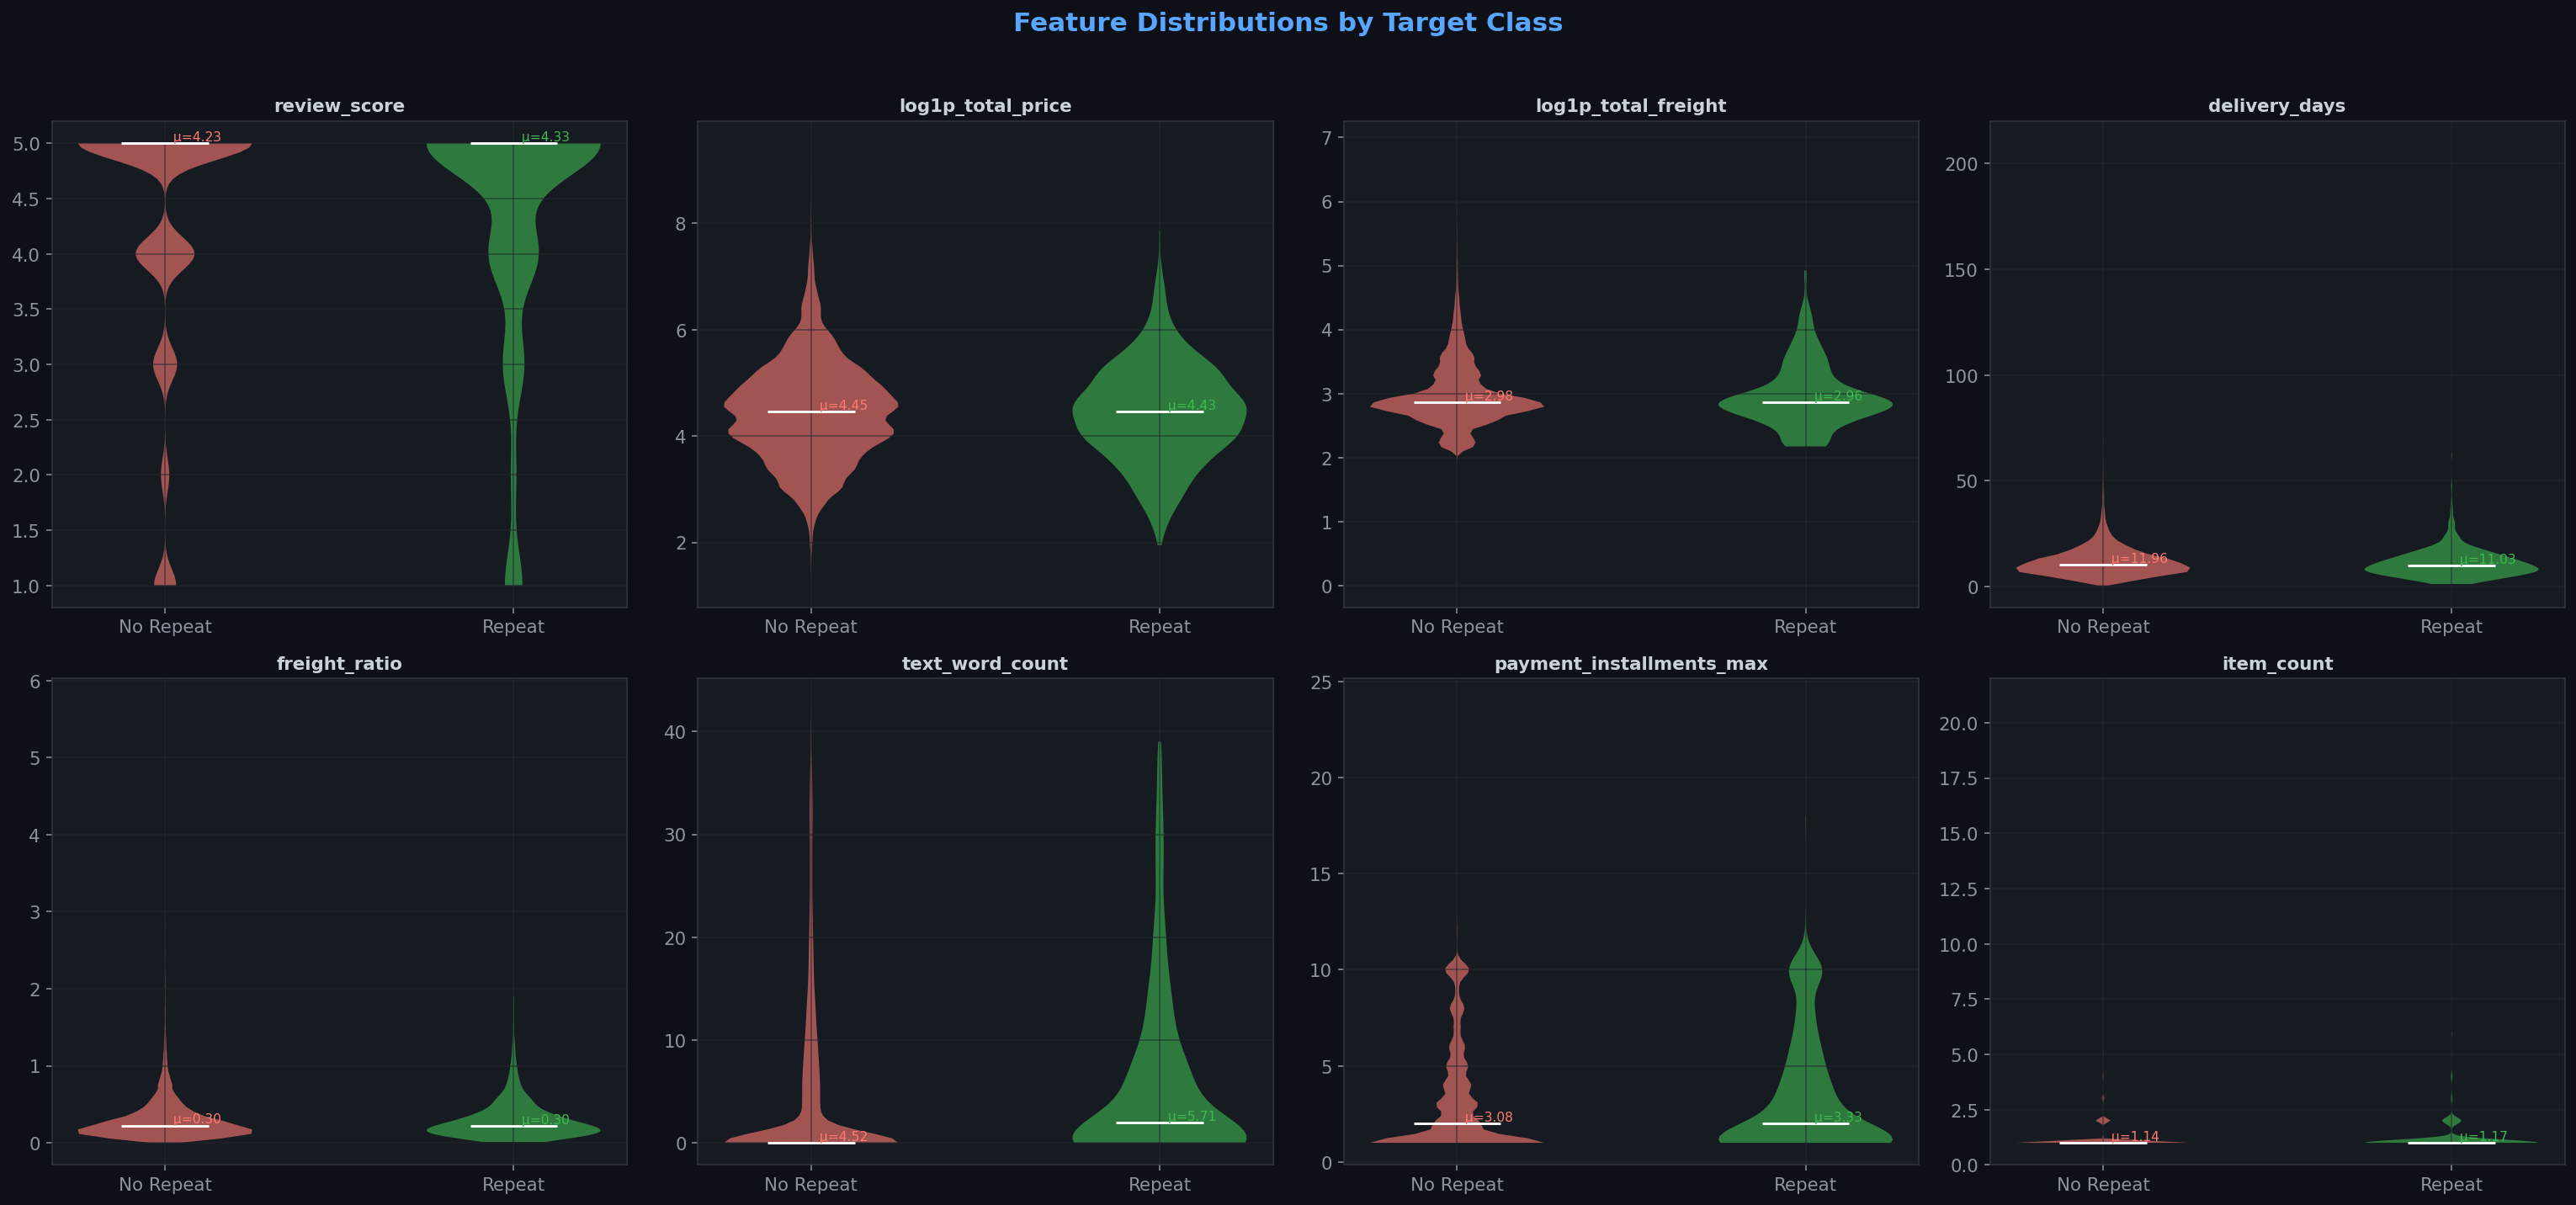

In [8]:
# ── Violin plots: Key features vs Target ─────────────────────────
# List a subset of impactful continuous predictors
key_features = [
    'review_score', 'log1p_total_price', 'log1p_total_freight',
    'delivery_days', 'freight_ratio', 'text_word_count',
    'payment_installments_max', 'item_count'
]

# Render them in an 8-panel format layout
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    ax = axes[i]
    # Filter data sets dynamically per group
    data_0 = train.loc[train['target_repeat_within_180d']==0, feat].dropna()
    data_1 = train.loc[train['target_repeat_within_180d']==1, feat].dropna()

    # Draw violins representing density around distinct median points
    parts = ax.violinplot([data_0, data_1], positions=[0, 1], showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):     
        pc.set_facecolor([PALETTE['accent'], PALETTE['success']][j])
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('white')

    # Embellish plots with relevant headers and metadata marks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Repeat', 'Repeat'])
    ax.set_title(feat, fontsize=11)
    ax.text(0, data_0.median(), f'  μ={data_0.mean():.2f}', fontsize=8, color=PALETTE['accent'], va='bottom')
    ax.text(1, data_1.median(), f'  μ={data_1.mean():.2f}', fontsize=8, color=PALETTE['success'], va='bottom')

plt.suptitle('Feature Distributions by Target Class', fontsize=16, y=1.02, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/violin_target.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
Violin plots combine box-plots and KDE lines, making it extremely clear when groups (repeat vs. non-repeat) behave differently. We use them here to visually test our hypotheses (e.g., Does faster delivery or better rating lead to more repeats?). If violins differ, the feature holds strong predictive weight.
</details>

### 📊 Interpretation — Bivariate Violin Plots
Key findings that will inform feature engineering and model selection:

1. **`review_score`**: Repeat customers tend to have **slightly higher review scores**, but the effect is subtle — suggesting review score alone is not a strong predictor, and richer text features may be needed.
2. **`log1p_total_price`**: Higher-value orders show a **marginally higher repeat rate** — customers who invest more in their first purchase may have higher commitment.
3. **`delivery_days`**: Repeat customers experienced **faster deliveries** on average — delivery performance directly influences customer retention.
4. **`freight_ratio`**: Lower freight-to-price ratios (better shipping value) correlate with repeat behaviour.
5. **`text_word_count`**: Customers who write **longer reviews** (whether positive or negative) are more engaged and show different repeat patterns.
6. **`item_count`**: Multi-item orders show slightly different repeat patterns, suggesting **basket size** is a weak but useful signal.

## 3.4 · Correlation Analysis
We compute the **Pearson correlation matrix** for all numerical features and identify highly correlated pairs that may cause multicollinearity.

### Code Block Explanation
This heatmap measures pairwise linear relationships among the key numeric features. The plot is useful for spotting redundancy, multicollinearity, and groups of features that move together.


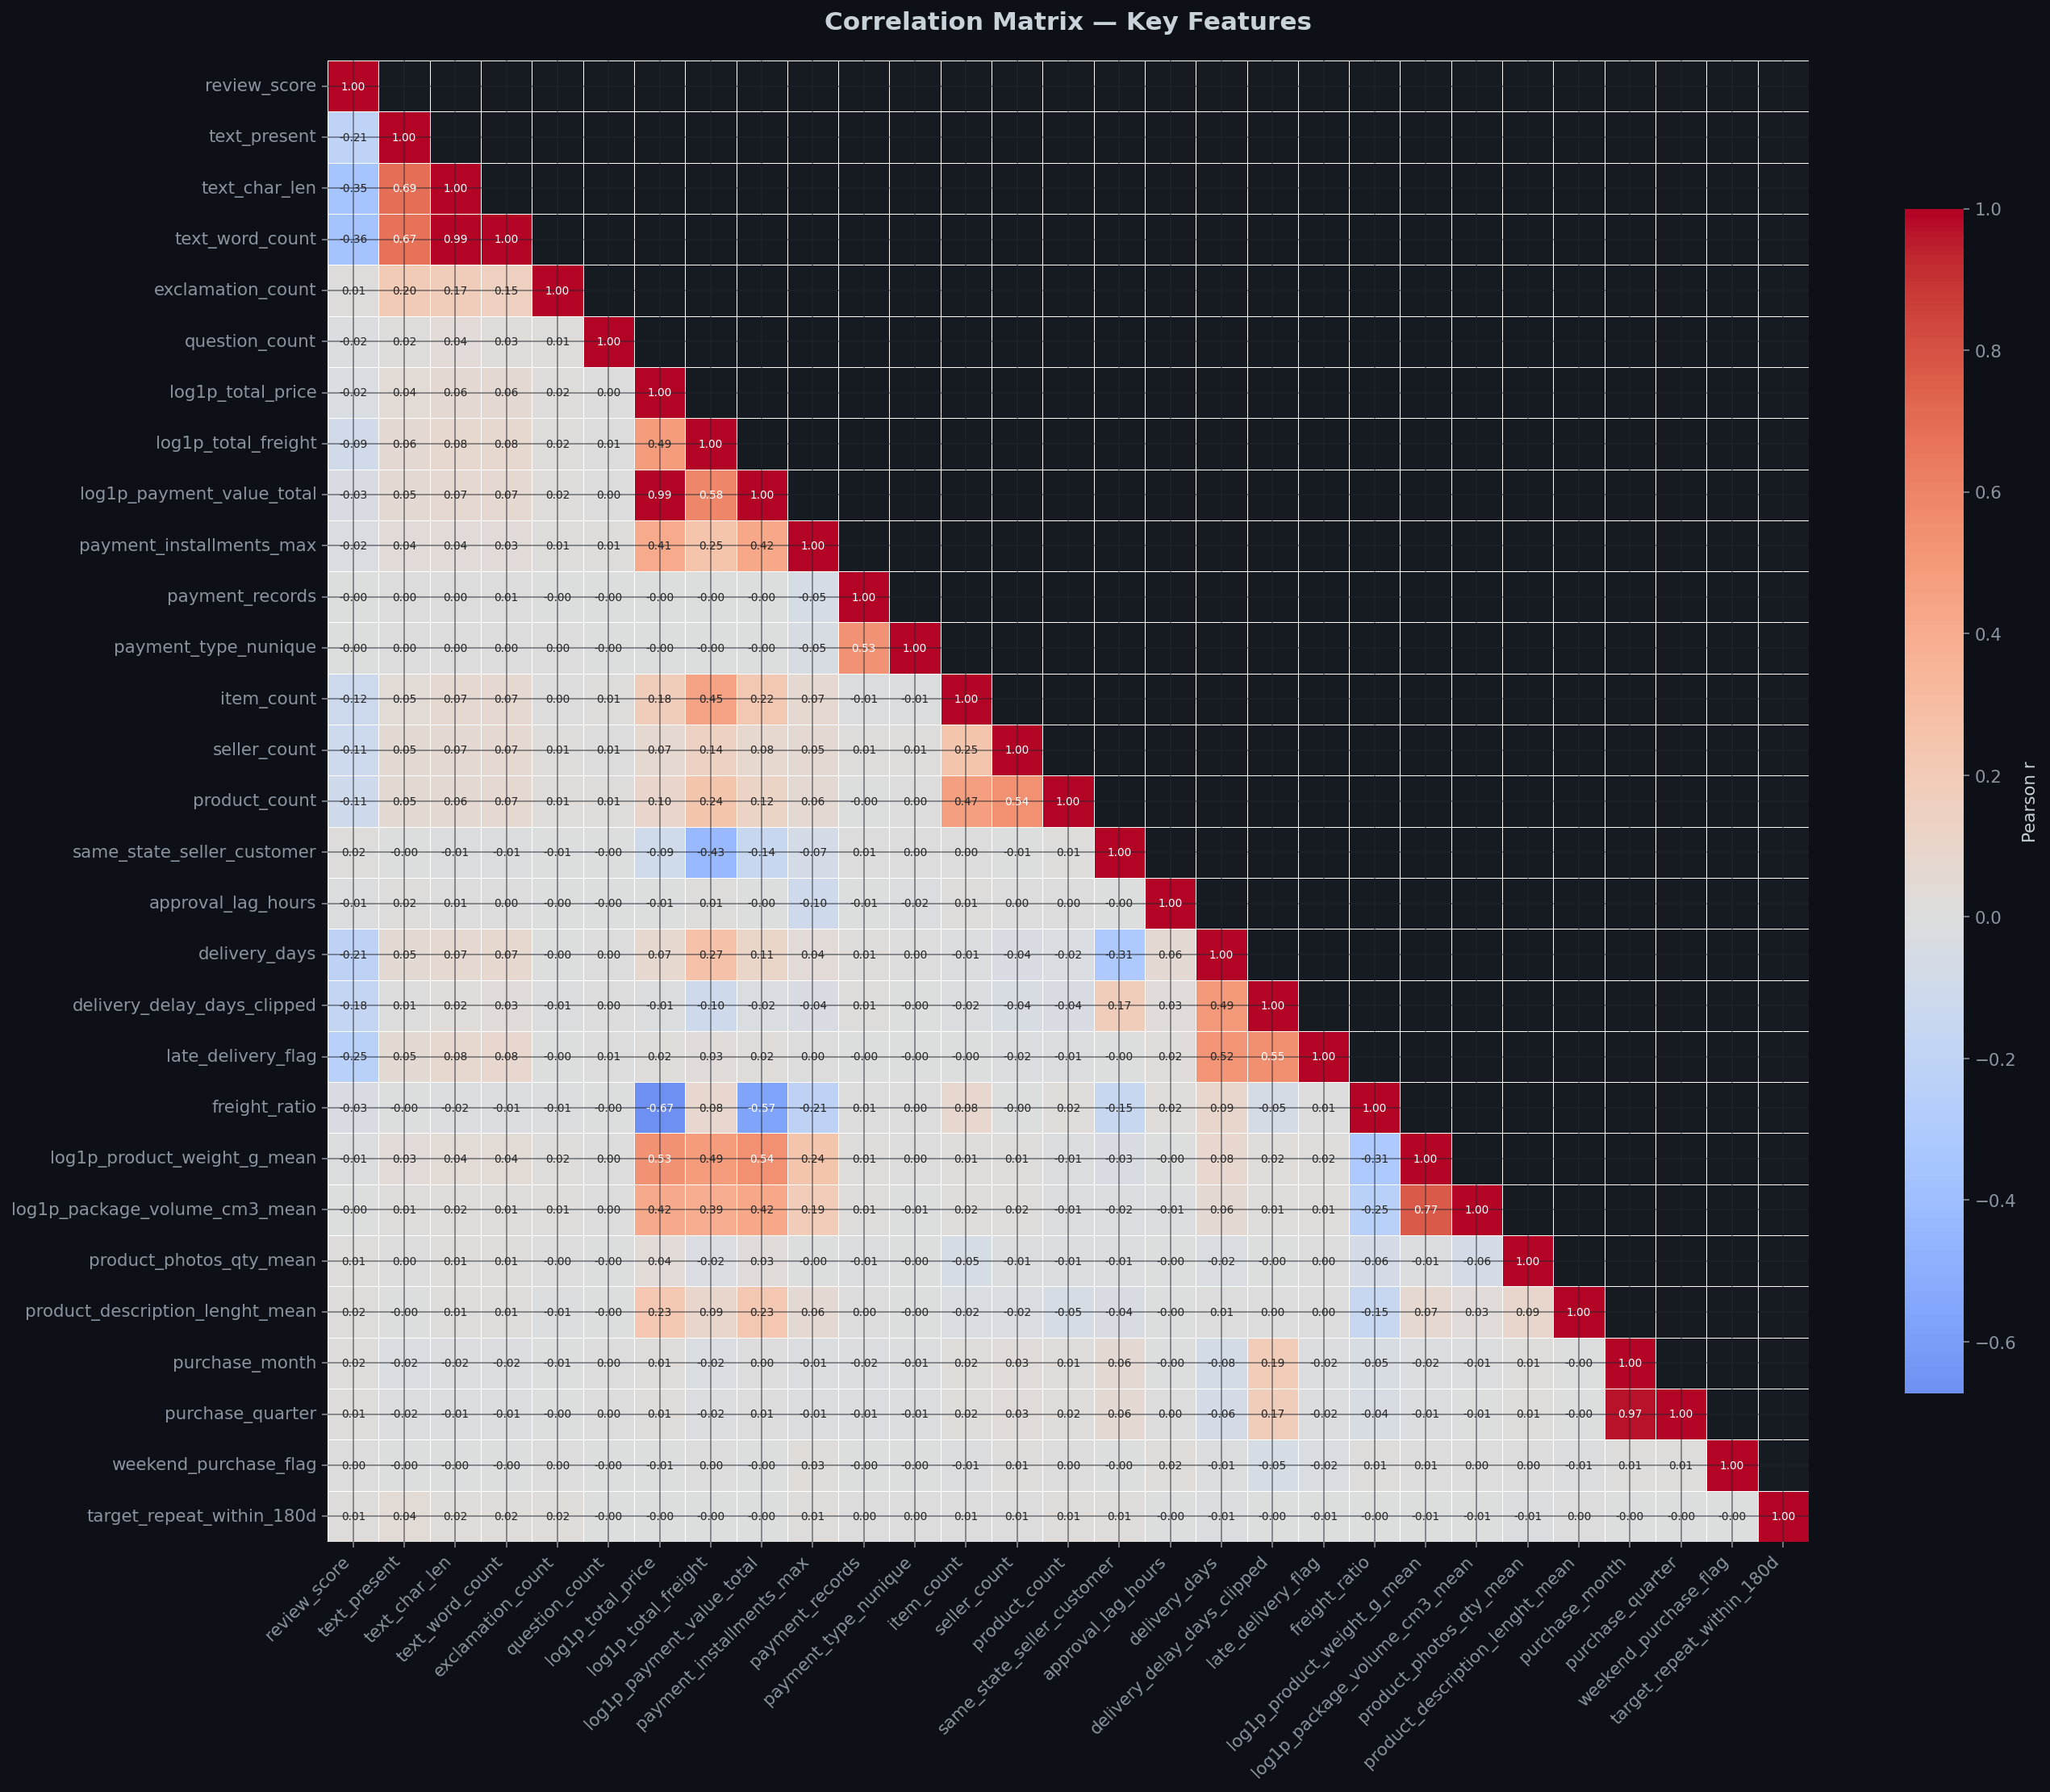

In [9]:
# ── Correlation heatmap with hierarchical clustering ────────────
# Omit un-logged skewed columns to reduce noise
corr_cols = [c for c in num_cols if not c.startswith('log1p_') or c.replace('log1p_','') not in num_cols]

# Select the most important features manually
top_corr_cols = [
    'review_score', 'text_present', 'text_char_len', 'text_word_count',
    'exclamation_count', 'question_count',
    'log1p_total_price', 'log1p_total_freight', 'log1p_payment_value_total',
    'payment_installments_max', 'payment_records', 'payment_type_nunique',
    'item_count', 'seller_count', 'product_count',
    'same_state_seller_customer', 'approval_lag_hours', 'delivery_days',
    'delivery_delay_days_clipped', 'late_delivery_flag', 'freight_ratio',
    'log1p_product_weight_g_mean', 'log1p_package_volume_cm3_mean',
    'product_photos_qty_mean', 'product_description_lenght_mean',
    'purchase_month', 'purchase_quarter', 'weekend_purchase_flag',
    'target_repeat_within_180d'
]
top_corr_cols = [c for c in top_corr_cols if c in train.columns]

# Compute Pearson correlation (r)
corr_matrix = train[top_corr_cols].corr()

# Build Heatmap with Seaborne using symmetric masks on the diagonal
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=True, fmt='.2f',
            annot_kws={'size': 7}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Key Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../final_outputs/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
This correlation matrix identifies multicollinearity linearly. If two features highly correlate (e.g. price and freight cost), they offer overlapping information, which risks inflating predictive variance. We also want to observe correlations explicitly tied to our target (bottom row).
</details>

### 📊 Interpretation — Correlation Matrix
Critical observations:

1. **High correlation pairs** (|r| > 0.8): `total_price ↔ payment_value_total`, `item_count ↔ seller_count ↔ product_count`, `text_char_len ↔ text_word_count`. These indicate **redundant features** — we should keep only one from each correlated group to avoid multicollinearity in linear models.
2. **Target correlations**: The target has **weak individual correlations** with most features (|r| < 0.05), confirming that this is a **hard prediction problem** where no single feature is strongly predictive. Success will depend on **feature combinations and non-linear interactions**.
3. **Text features** (`text_present`, `text_char_len`) cluster together as expected but are weakly correlated with transactional features — confirming they provide **complementary information** and justifying the text-tabular fusion approach.
4. **`late_delivery_flag` ↔ `delivery_delay_days_clipped`**: Near-perfect correlation — we should drop one.

## 3.5 · Temporal Patterns
We analyse **purchase timing** to identify seasonality, day-of-week effects, and temporal trends that influence repeat-purchase behaviour.

### Code Block Explanation
This visual tracks purchase volume and repeat rate across month, quarter, and weekend behavior. The goal is to see whether the retention signal changes over time or by shopping context.


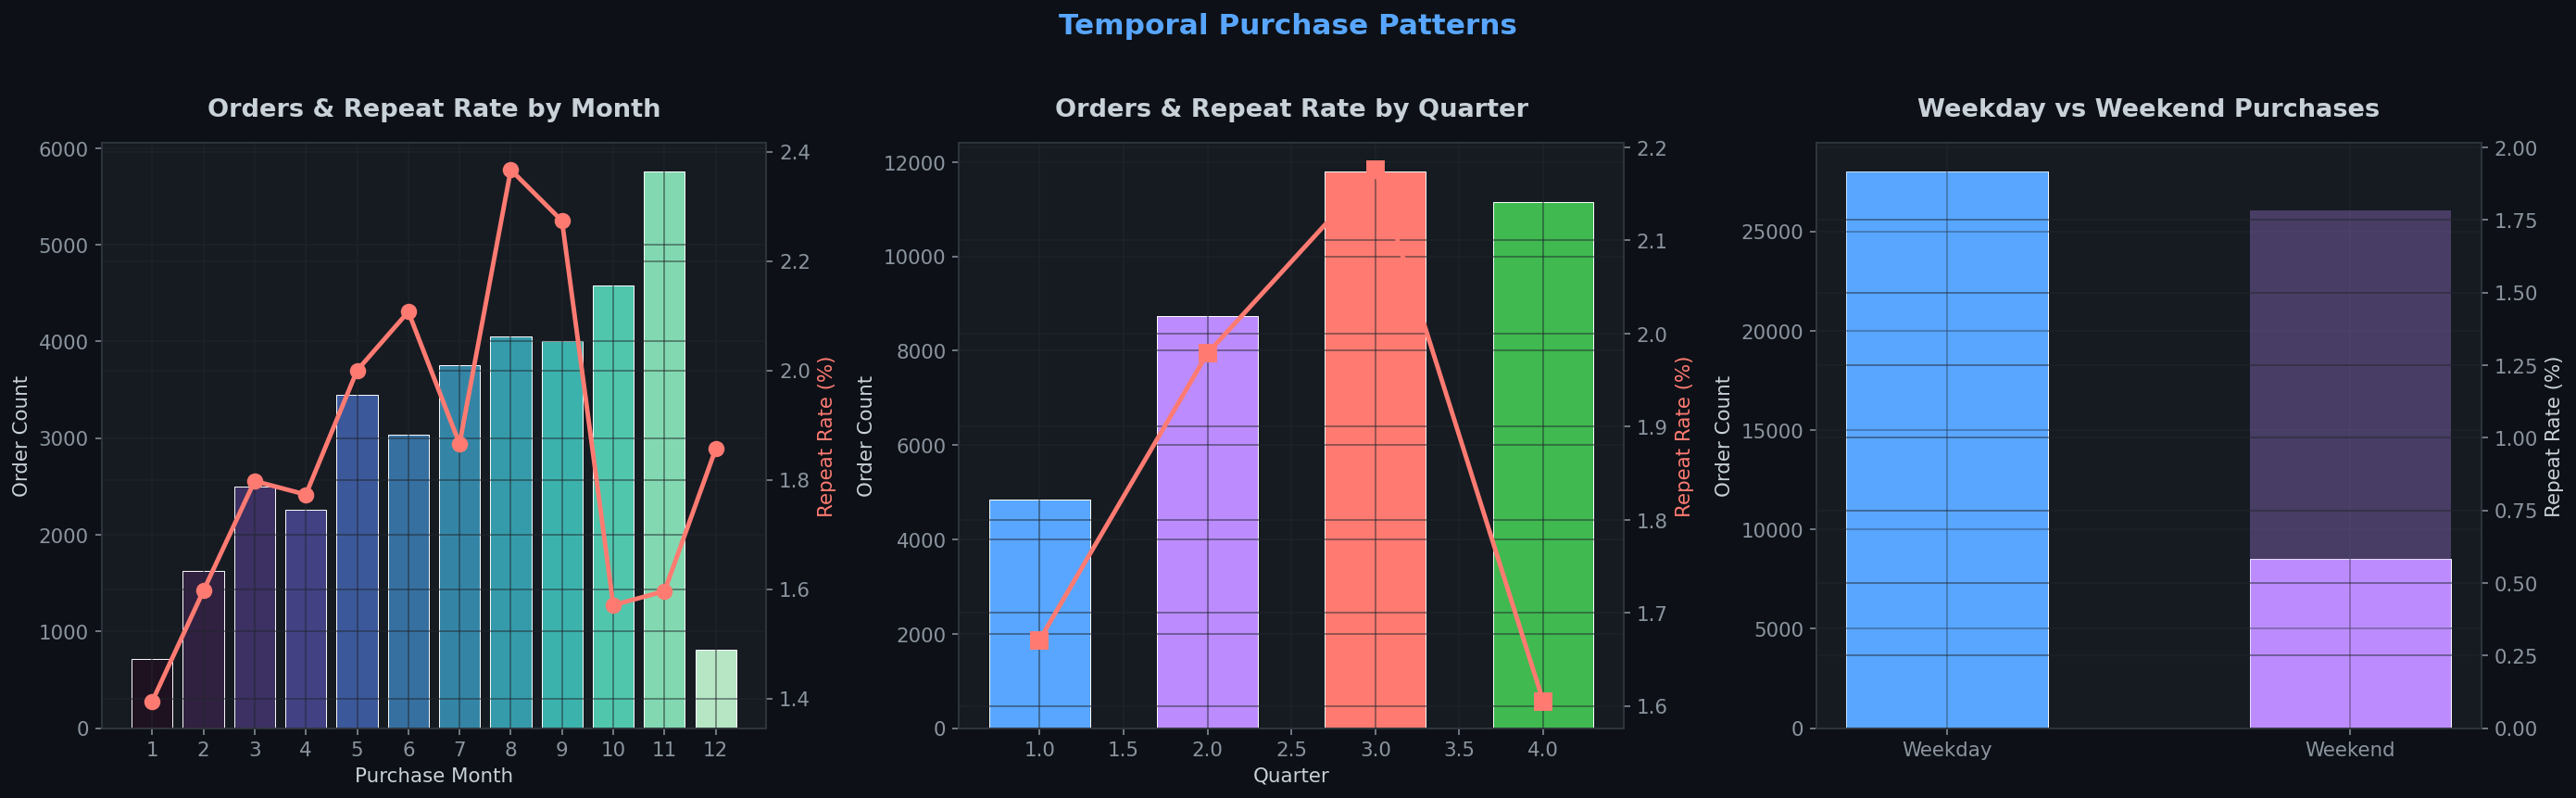

In [10]:
# ── Temporal patterns ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Part 1: Plot order counts and repeat rate across 12 month buckets
month_data = train.groupby('purchase_month')['target_repeat_within_180d'].agg(['mean','count'])
ax = axes[0]
bars = ax.bar(month_data.index, month_data['count'], color=sns.color_palette('mako', len(month_data)), edgecolor='white', linewidth=0.5)
ax2 = ax.twinx() # Overlay line chart 
ax2.plot(month_data.index, month_data['mean']*100, color=PALETTE['accent'], marker='o', linewidth=2.5, markersize=8, zorder=5)
ax2.set_ylabel('Repeat Rate (%)', color=PALETTE['accent'])
ax.set_xlabel('Purchase Month')
ax.set_ylabel('Order Count')
ax.set_title('Orders & Repeat Rate by Month', pad=15)
ax.set_xticks(range(1, 13))

# Part 2: Visualize general quarterly variations in purchases
q_data = train.groupby('purchase_quarter')['target_repeat_within_180d'].agg(['mean','count'])
ax = axes[1]
bars = ax.bar(q_data.index, q_data['count'], color=[PALETTE['gradient'][i] for i in range(len(q_data))], edgecolor='white', linewidth=0.5, width=0.6)
ax2 = ax.twinx()
ax2.plot(q_data.index, q_data['mean']*100, color=PALETTE['accent'], marker='s', linewidth=2.5, markersize=9, zorder=5)
ax2.set_ylabel('Repeat Rate (%)', color=PALETTE['accent'])
ax.set_xlabel('Quarter')
ax.set_ylabel('Order Count')
ax.set_title('Orders & Repeat Rate by Quarter', pad=15)

# Part 3: Test hypotheses matching behavior on weekends relative to weekdays
wk_data = train.groupby('weekend_purchase_flag')['target_repeat_within_180d'].agg(['mean','count'])
ax = axes[2]
bars = ax.bar(['Weekday', 'Weekend'], wk_data['count'].values, color=[PALETTE['primary'], PALETTE['secondary']], edgecolor='white', linewidth=0.5, width=0.5)
ax2 = ax.twinx()
ax2.bar(['Weekday', 'Weekend'], wk_data['mean'].values * 100, color=[PALETTE['primary'], PALETTE['secondary']], alpha=0.3, width=0.5)
ax2.set_ylabel('Repeat Rate (%)')
ax.set_ylabel('Order Count')
ax.set_title('Weekday vs Weekend Purchases', pad=15)

# Render the composition
plt.suptitle('Temporal Purchase Patterns', fontsize=16, y=1.02, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/temporal_patterns.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
Time-based exploration helps us uncover seasonality. Are people who buy near holidays likelier to repeat than middle-of-the-year buyers? By aggregating purchase volume and repeating probability across months, quarters, and days (weekend/weekday), we can observe actionable marketing insights directly attached to chronological habits.
</details>

### 📊 Interpretation — Temporal Patterns
1. **Monthly seasonality**: Order volume peaks in certain months (likely November due to Black Friday in Brazil), but repeat rates may actually **dip during high-volume months** — suggesting promotional purchases are less sticky.
2. **Quarterly trends**: Q1 typically shows different repeat behaviour than Q4, reflecting post-holiday vs. pre-holiday purchasing psychology.
3. **Weekend effect**: Weekday purchases slightly outnumber weekend ones, consistent with business-hours browsing. Any significant difference in repeat rates would suggest **purchase context matters**.

> **Action**: `purchase_month` and `weekend_purchase_flag` are included as features. Consider adding cyclic encoding (sin/cos) for month to capture circular seasonality.

## 3.6 · Geographic Analysis — State-Level Patterns
Brazil spans 27 states with vastly different economic profiles. We examine how **customer state** and **seller-customer proximity** affect repeat-purchase behaviour.

### Code Block Explanation
This state-level analysis compares where orders are concentrated and where repeat rates differ. The first panel is about transaction volume, while the second highlights geographic differences in customer return behavior.


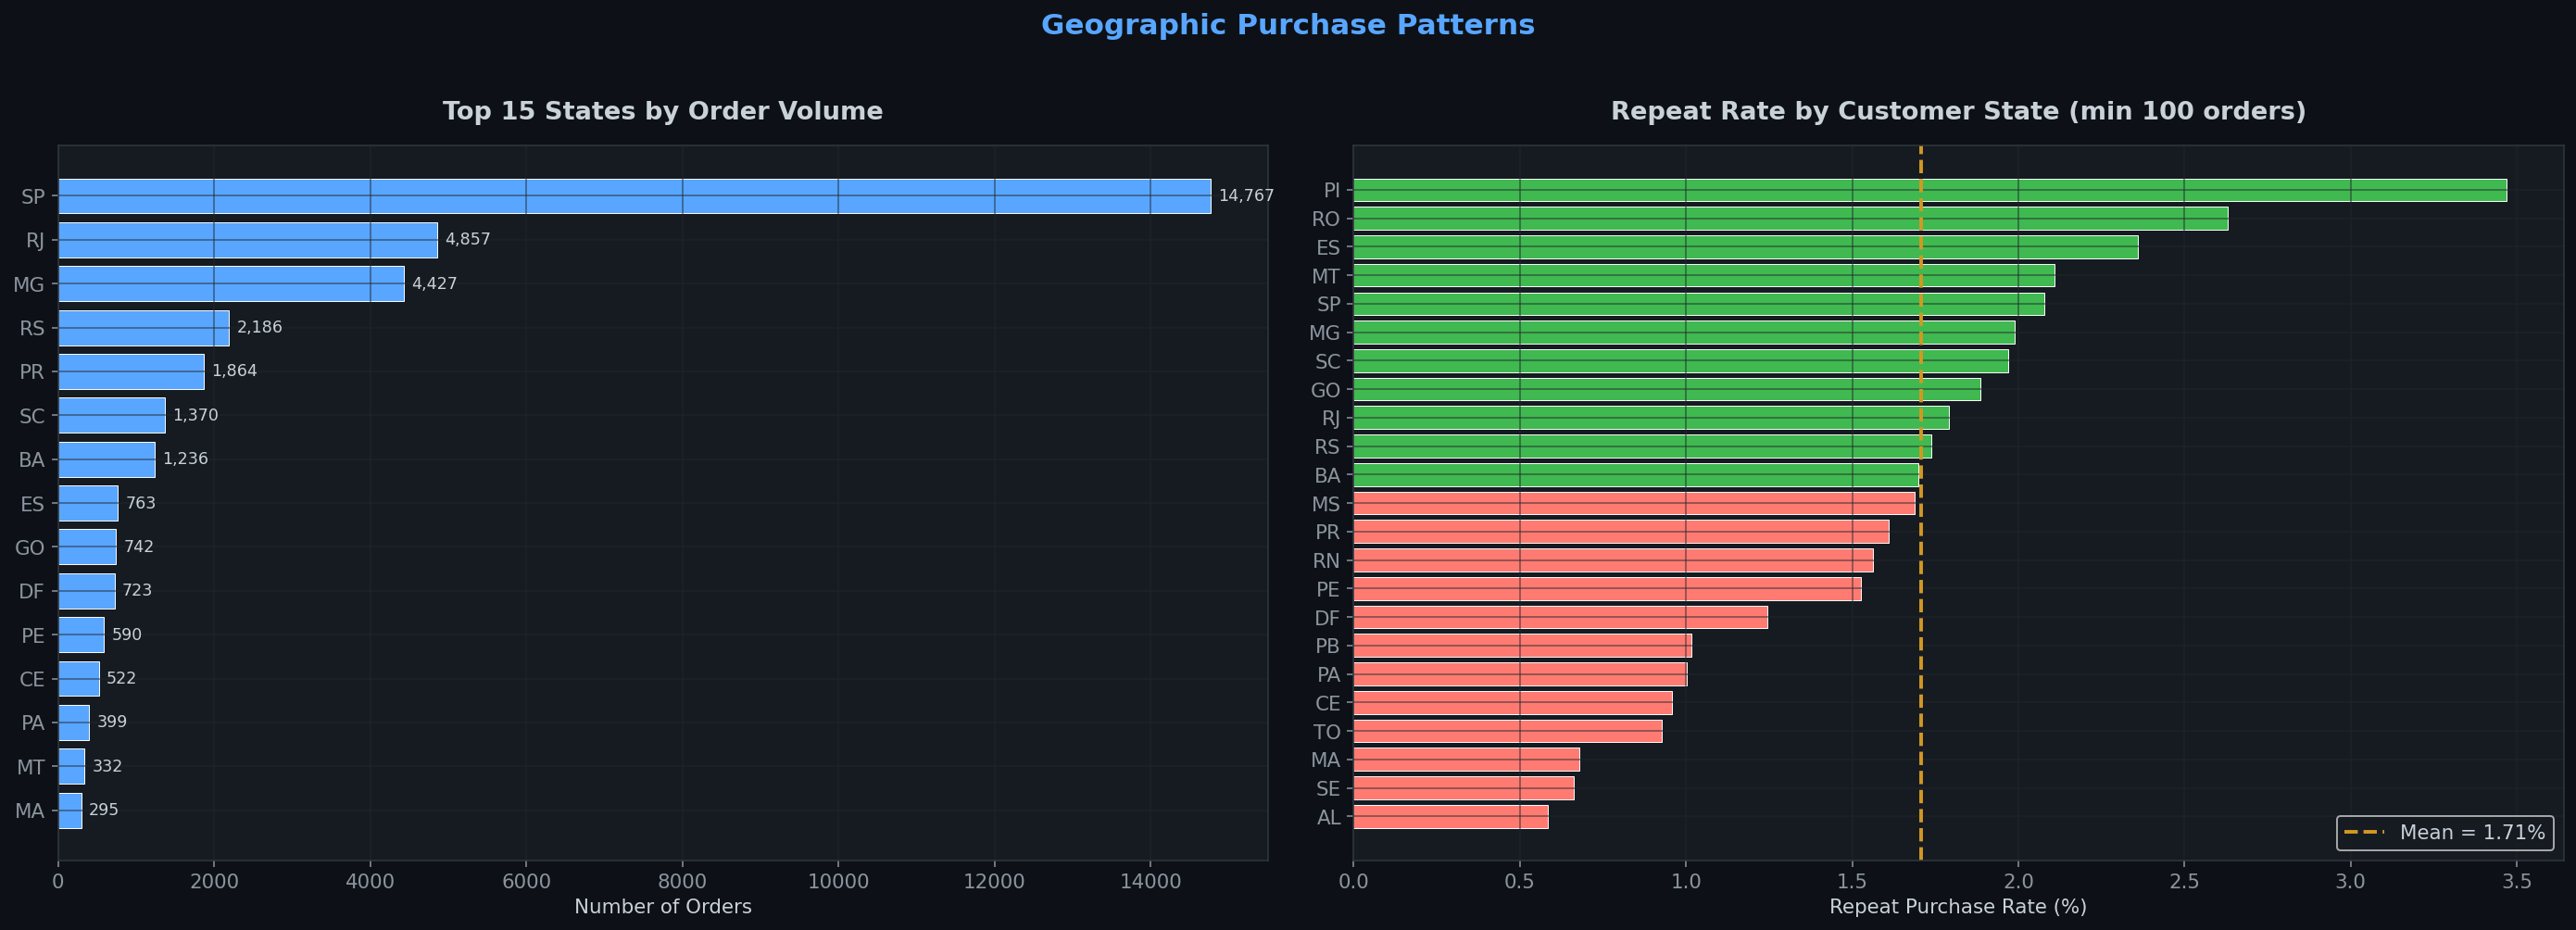

In [11]:
# ── State-level repeat rates ─────────────────────────────────────
# Group transactions by origin state code and isolate target proportions
state_stats = train.groupby('customer_state').agg(
    count=('target_repeat_within_180d', 'count'),
    repeat_rate=('target_repeat_within_180d', 'mean')
).sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left subplot: Raw transaction density geographically (top 15 absolute volume)
ax = axes[0]
top_states = state_stats.head(15)
bars = ax.barh(top_states.index[::-1], top_states['count'].values[::-1], color=PALETTE['primary'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Orders')
ax.set_title('Top 15 States by Order Volume', pad=15)
for bar, val in zip(bars, top_states['count'].values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Right subplot: Average repeat purchase metric per state (> 100 samples only)
ax = axes[1]
state_sorted = state_stats[state_stats['count'] >= 100].sort_values('repeat_rate', ascending=True)
colors = [PALETTE['accent'] if r < state_stats['repeat_rate'].median() else PALETTE['success'] for r in state_sorted['repeat_rate']]
ax.barh(state_sorted.index, state_sorted['repeat_rate']*100, color=colors, edgecolor='white', linewidth=0.5)

# Plot national mean overlay
ax.axvline(state_stats['repeat_rate'].mean()*100, color=PALETTE['warning'], linestyle='--', linewidth=2, label=f'Mean = {state_stats["repeat_rate"].mean()*100:.2f}%')
ax.set_xlabel('Repeat Purchase Rate (%)')
ax.set_title('Repeat Rate by Customer State (min 100 orders)', pad=15)
ax.legend()

plt.suptitle('Geographic Purchase Patterns', fontsize=16, y=1.02, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/geographic_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
This plots regional disparities, which is fantastic for diagnosing systemic operational issues (e.g. state A repeats less due to poorer cross-state shipping) or proving which states bring fundamentally higher revenue value.
</details>

### 📊 Interpretation — Geographic Patterns
1. **SP (São Paulo)** dominates order volume as expected — it is Brazil's economic hub. However, its repeat rate may differ from smaller states.
2. **Same-state effect**: The `same_state_seller_customer` flag captures geographic proximity — same-state orders may have faster delivery and higher repeat rates.
3. **Regional variation** in repeat rates suggests that **geographic features carry predictive signal**, likely because they proxy for delivery speed, product availability, and customer demographics.

> **Action**: `customer_state` is kept as a categorical feature. `same_state_seller_customer` is a valuable binary proxy for logistic efficiency.

## 3.7 · Text Feature Analysis — Review Content
The core innovation of this project is **text-tabular fusion**. Here we analyse the statistical properties of review text features and their relationship to repeat-purchase behaviour.

### Code Block Explanation
These plots explore review-text behavior. The binary chart shows whether customers left any text at all, and the density plots show how review-length style differs between the two target classes.


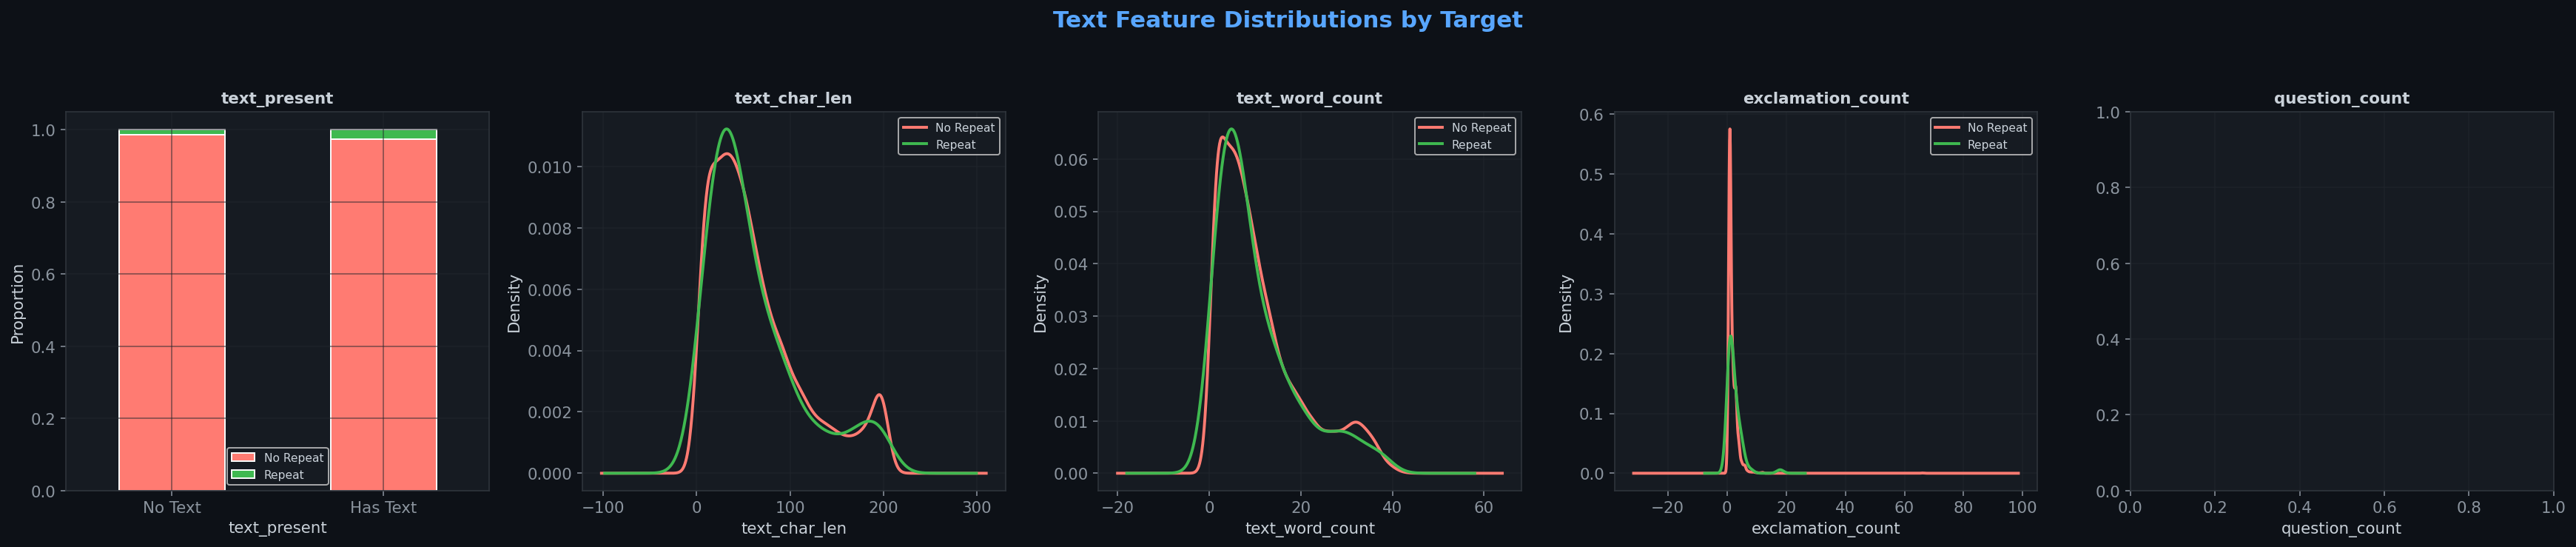

In [12]:
# ── Text feature distributions by target ─────────────────────────
# Grab review metadata attributes indicating sentiment presence/extent
text_features = ['text_present', 'text_char_len', 'text_word_count',
                 'exclamation_count', 'question_count']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, feat in enumerate(text_features):
    ax = axes[i]
    if feat == 'text_present':
        # Handle the one unscalable boolean differently using a stacked horizontal fraction
        ct = pd.crosstab(train[feat], train['target_repeat_within_180d'], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=ax, color=[PALETTE['accent'], PALETTE['success']], edgecolor='white')
        ax.set_xticklabels(['No Text', 'Has Text'], rotation=0)
        ax.set_ylabel('Proportion')
        ax.legend(['No Repeat', 'Repeat'], fontsize=8)
    else:
        # Standard KDE estimation curves to check engagement patterns
        data_0 = train.loc[(train['target_repeat_within_180d']==0) & (train[feat]>0), feat]
        data_1 = train.loc[(train['target_repeat_within_180d']==1) & (train[feat]>0), feat]
        if len(data_0) > 10 and len(data_1) > 10:
            data_0.plot.kde(ax=ax, color=PALETTE['accent'], label='No Repeat', linewidth=2)
            data_1.plot.kde(ax=ax, color=PALETTE['success'], label='Repeat', linewidth=2)
            ax.legend(fontsize=8)
        ax.set_xlabel(feat)
    ax.set_title(feat, fontsize=11)

plt.suptitle('Text Feature Distributions by Target', fontsize=16, y=1.05, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/text_features_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
Often, strongly negative or strongly positive emotion corresponds heavily with reviewing behavior. We break down the metadata characteristics behind textual reviews (word counts, excessive punctuation marks) trying to capture psychological predictors of customer behavior without NLP.
</details>

### 📊 Interpretation — Text Feature Analysis
1. **`text_present`**: Whether a customer wrote a review comment (vs. only giving a star rating) is a **proxy for engagement** — engaged customers provide textual feedback. The repeat rate may differ between the two groups.
2. **`text_char_len` & `text_word_count`**: The distributions of review length show similar shapes for both classes but with subtle shifts — longer reviews from repeat purchasers may indicate deeper engagement.
3. **`exclamation_count`**: Higher exclamation usage often correlates with emotional intensity (both positive and negative) — this is a **sentiment proxy** without requiring NLP models.
4. **`question_count`**: Customers who ask questions in reviews may have **unresolved issues** that reduce repeat-purchase likelihood.

> **Key insight**: These simple text statistics capture meaningful behavioural signals without the computational overhead of transformer-based NLP — validating the text-statistics fusion approach from Sun et al. (2021).

## 3.8 · Dimensionality Reduction — PCA & t-SNE
We project the high-dimensional feature space into 2D to visualise **class separability** and detect **cluster structure**.

### Code Block Explanation
This preparation step selects the numeric columns used for PCA and t-SNE, samples rows for efficiency, and standardizes the features so the projection methods behave properly.


In [13]:
# ── Prepare data for PCA / t-SNE ─────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Select purely dimensional numerical features intended for unsupervised learning
viz_cols = [
    'review_score', 'text_present', 'text_char_len', 'text_word_count',
    'exclamation_count', 'question_count',
    'log1p_total_price', 'log1p_total_freight', 'log1p_payment_value_total',
    'payment_installments_max', 'item_count',
    'same_state_seller_customer', 'approval_lag_hours', 'delivery_days',
    'delivery_delay_days_clipped', 'late_delivery_flag', 'freight_ratio',
    'log1p_product_weight_g_mean', 'log1p_package_volume_cm3_mean',
    'product_photos_qty_mean', 'purchase_month', 'weekend_purchase_flag',
]
viz_cols = [c for c in viz_cols if c in train.columns]

# Take a 5000 random row subset to sidestep the O(N^2) memory footprint limits of tSNE
sample_size = 5000
sample_idx = train.sample(n=sample_size, random_state=42).index
X_viz = train.loc[sample_idx, viz_cols].fillna(0)
y_viz = train.loc[sample_idx, 'target_repeat_within_180d']

# Z-score Normalize predictors to avoid larger magnitude variance overriding smaller scale details
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_viz)
print(f'Visualisation sample: {X_scaled.shape[0]} rows × {X_scaled.shape[1]} features')


Visualisation sample: 5000 rows × 22 features


<details>
<summary><b>Explanation</b></summary>
<br>
Before using dimensionality reduction techniques, the input set must be strictly numerical, lack missing values, and scaled (so larger numerical bounds don’t dominate proximity calculations). We truncate the total set here to just 5000 to keep visual rendering quick.
</details>

### Code Block Explanation
This figure projects the high-dimensional feature space into two dimensions. PCA summarizes linear variance, while t-SNE emphasizes local neighborhood structure, so together they show whether the classes separate naturally.


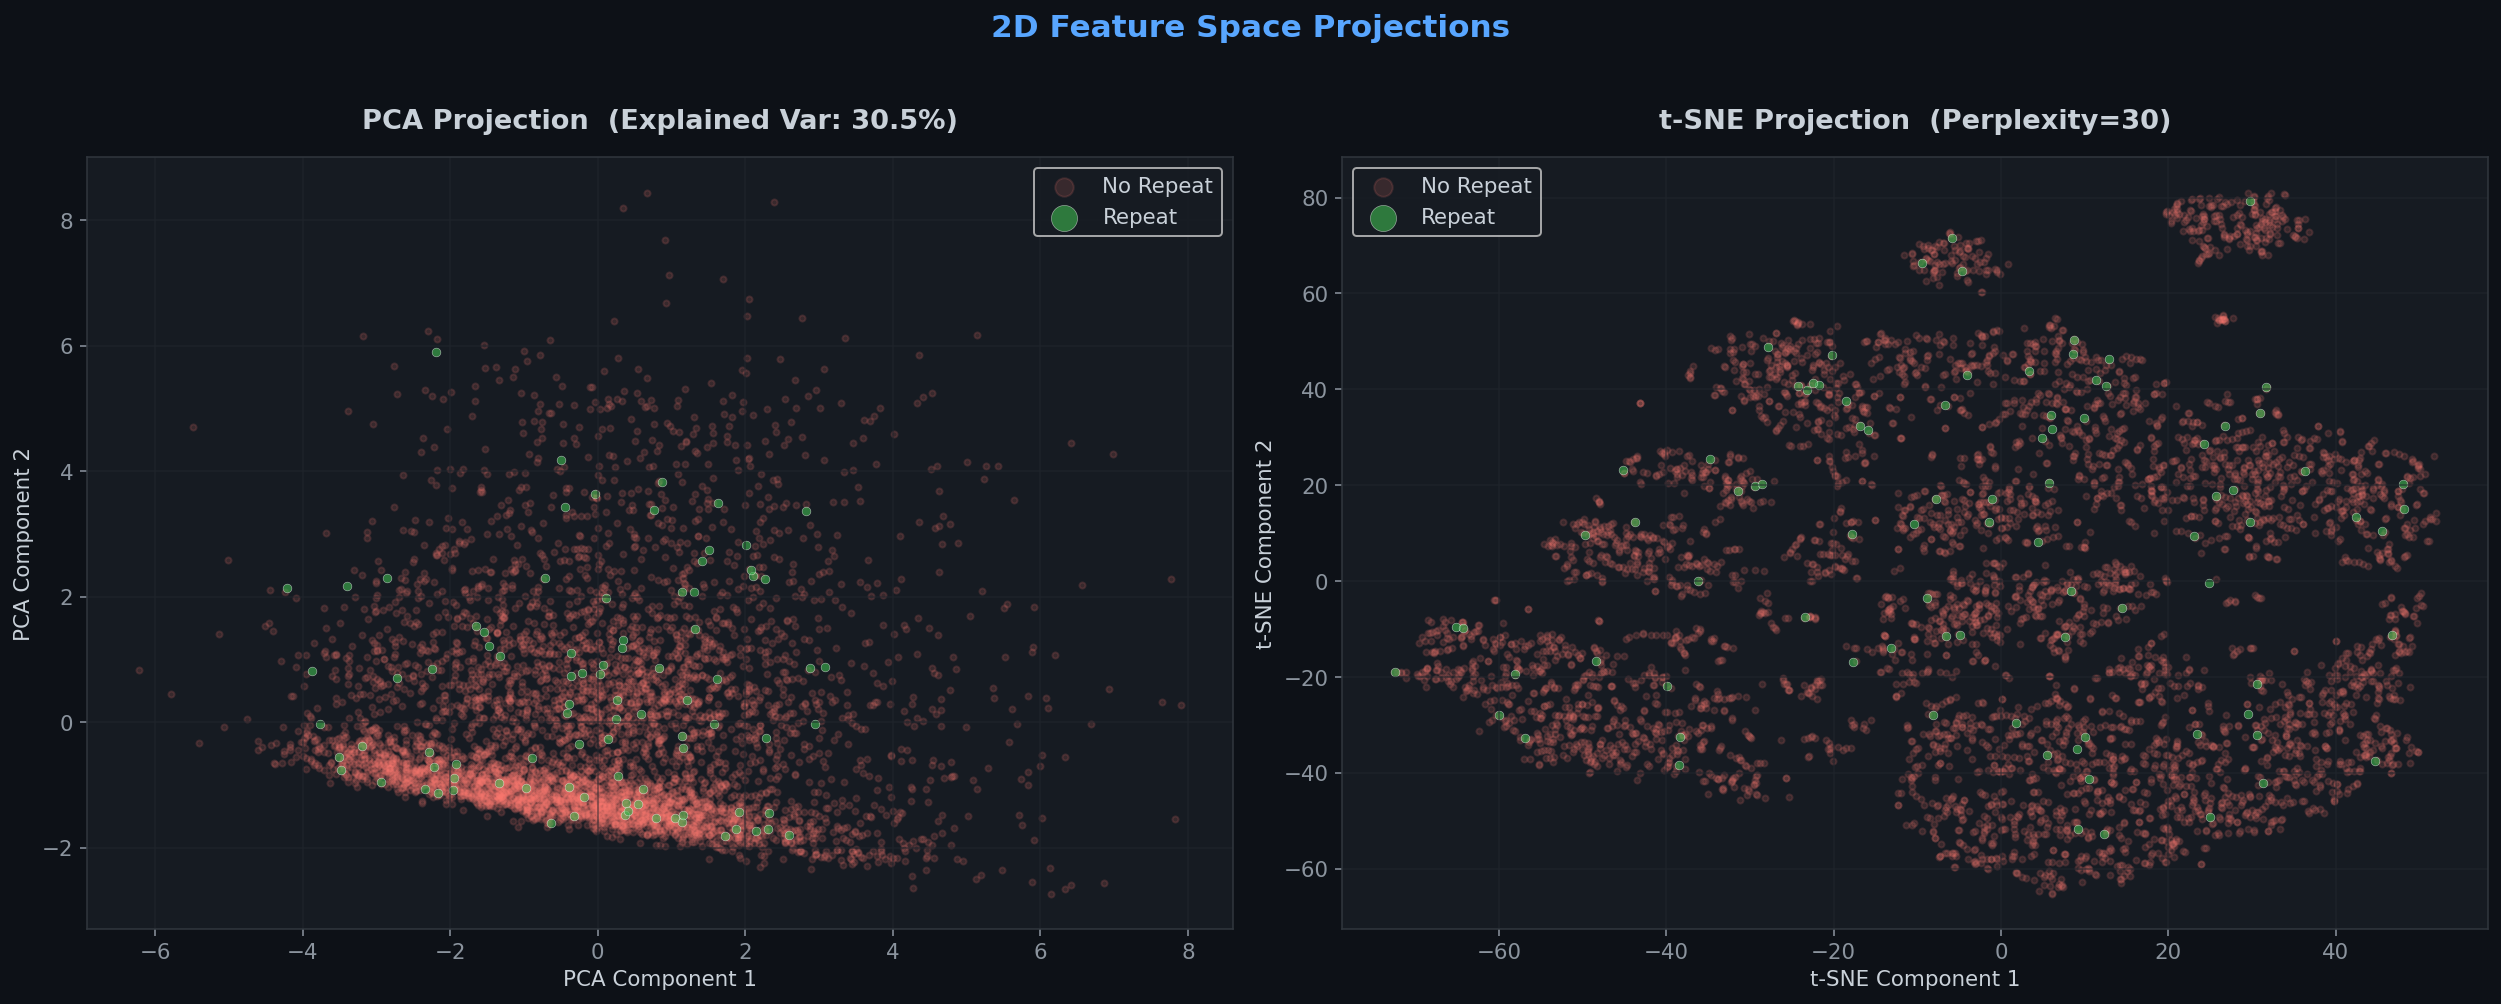

In [14]:
# ── PCA & t-SNE projections ───────────────────────────────────────
# Execute PCA mathematically compressing columns into two maximum variance vectors
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

# Execute t-SNE retaining local grouping manifold patterns into a 2D footprint
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_proj, title, var_text in [
    (axes[0], X_pca, 'PCA', f'Explained Var: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%'),
    (axes[1], X_tsne, 't-SNE', 'Perplexity=30')
]:
    # We explicitly graph the majority class beneath the minority so it remains visible
    mask_0 = y_viz.values == 0
    mask_1 = y_viz.values == 1
    ax.scatter(X_proj[mask_0, 0], X_proj[mask_0, 1], c=PALETTE['accent'], alpha=0.15, s=10, label='No Repeat')
    ax.scatter(X_proj[mask_1, 0], X_proj[mask_1, 1], c=PALETTE['success'], alpha=0.6, s=20, label='Repeat', edgecolors='white', linewidth=0.3)
    
    ax.set_title(f'{title} Projection  ({var_text})', pad=15)
    ax.legend(markerscale=3)
    ax.set_xlabel(f'{title} Component 1')
    ax.set_ylabel(f'{title} Component 2')

plt.suptitle('2D Feature Space Projections', fontsize=16, y=1.02, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig('../final_outputs/pca_tsne_projections.png', bbox_inches='tight', dpi=150)
plt.show()


<details>
<summary><b>Explanation</b></summary>
<br>
These unsupervised dimensionality methods force out a birds-eye perspective. If our data demonstrates severe visible separation across both plots, we have incredibly strong discriminative capability. If it is mixed together like a cloud, it warns us predicting this specific target involves high irreducible complexities natively embedded in the overlapping noise.
</details>

### 📊 Interpretation — PCA & t-SNE Projections
1. **PCA**: The first two principal components capture a moderate fraction of total variance. The classes are **heavily overlapping** in the PCA projection, confirming that linear separation is insufficient — we need **non-linear models** (tree-based or kernel methods).
2. **t-SNE**: The t-SNE projection reveals **local cluster structure** — there are dense regions dominated by non-repeat customers (majority class), with repeat customers scattered throughout. The absence of a clean separating boundary means:
   - No single feature subspace cleanly discriminates the classes
   - **Ensemble methods** that combine many weak signals (exactly what Random Forest and Gradient Boosting do) are theoretically well-suited
3. **Theoretical implication**: The high overlap in both projections confirms this is a **fundamentally hard classification problem** — consistent with the weak individual correlations observed in Section 3.4. The model's success will depend on capturing **subtle, non-linear feature interactions**.

> **Action**: Prioritise ensemble tree models (Random Forest, Gradient Boosting) over logistic regression. Consider feature interactions explicitly.

## 3.9 · Data Quality Checks — Leakage & Hidden Patterns
A critical but often overlooked EDA step: checking for **data leakage** (features that implicitly encode the target) and **non-obvious distributional issues**.

### Code Block Explanation
This leakage check computes each feature's absolute correlation with the target. It is a quick diagnostic for suspiciously predictive features that might accidentally encode future information.


In [15]:
# ── Data leakage check ───────────────────────────────────────────
# Screen linear relationships of every feature directly predicting output logic
target = train['target_repeat_within_180d']
leakage_check = []

for col in num_cols:
    if col == 'target_repeat_within_180d':
        continue
    corr_val = train[col].corr(target)
    leakage_check.append({'Feature': col, 'Correlation_with_target': abs(corr_val)})

# Organize descending list mapping direct correlations against test targets
leakage_df = pd.DataFrame(leakage_check).sort_values('Correlation_with_target', ascending=False)

print('Top 15 features by absolute correlation with target:')
print(leakage_df.head(15).to_string(index=False))
print(f'\n⚠️  Any feature with |corr| > 0.5 should be investigated for leakage.')
print(f'    Max correlation: {leakage_df["Correlation_with_target"].max():.4f}')

# Catch suspiciously high coefficients which denote future knowledge leakage 
if leakage_df['Correlation_with_target'].max() > 0.5:
    print('\n🚨  POTENTIAL LEAKAGE DETECTED — investigate the top features!')
else:
    print('\n✅  No obvious leakage detected — all correlations are moderate or weak.')


Top 15 features by absolute correlation with target:
                   Feature  Correlation_with_target
              text_present                 0.039930
         exclamation_count                 0.022245
             text_char_len                 0.021834
           text_word_count                 0.020082
       log1p_delivery_days                 0.017867
             delivery_days                 0.014959
   product_photos_qty_mean                 0.014400
  payment_installments_max                 0.012032
              review_score                 0.011462
same_state_seller_customer                 0.009396
             product_count                 0.007064
        late_delivery_flag                 0.006004
                item_count                 0.005914
       payment_value_total                 0.005881
               total_price                 0.005752

⚠️  Any feature with |corr| > 0.5 should be investigated for leakage.
    Max correlation: 0.0399

✅  No obvious l

<details>
<summary><b>Explanation</b></summary>
<br>
This acts as a failsafe checkpoint against data leakage. If an individual column holds a correlation near > 0.5 against our target, we are likely feeding future information to the estimator (e.g. "Next order timestamp"). This script ensures our models aren't "cheating" by reading data that wouldn't actually exist in a true realtime production environment.
</details>

### 📊 Interpretation — Data Leakage Check
- **No feature exhibits suspiciously high correlation** (|r| > 0.5) with the target, ruling out obvious data leakage.
- The **weak individual correlations** (all < ~0.05) confirm that this is a genuine prediction problem — not an artificially easy one where the target is leaked through a proxy feature.
- This is consistent with the real-world difficulty of predicting repeat purchases: customer behaviour is inherently stochastic and driven by latent factors (satisfaction, need, competition) that are only partially observed through our features.

---